In [1]:
import pandas as pd
import numpy as np
import math

import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
from tabulate import tabulate

import random

from pymongo import MongoClient
import squic

In [2]:
# Set connection
client = MongoClient("mongodb://localhost:27017/")
db = client["bank"]
balances_collection = db["amlsim1K"]

In [3]:
# Fetch balance evolution data from MongoDB
cursor = balances_collection.find({}, {"_id": 0})  # Exclude MongoDB item ID

balances = list(cursor)

In [4]:
#df = pd.DataFrame([{**entry["balances"], "date": entry["date"]} for entry in data])

#print(df.shape) # must be (720, 1447)
#print(df.head())

#      | id1 | id2 | ... | id1446
# day1 |   
# day2 |        balances
# ...

In [5]:
# Check the number of unique dates in extracted data
dates = [entry["date"] for entry in balances]
print("Unique dates found:", len(set(dates)))  # Should be 720
print("First 5 dates:", sorted(set(dates))[:5])
print("Last 5 dates:", sorted(set(dates))[-5:])

Unique dates found: 200
First 5 dates: [0, 1, 2, 3, 4]
Last 5 dates: [195, 196, 197, 198, 199]


In [6]:
df = pd.DataFrame([
    {key: value["balance"] for key, value in entry["balances"].items()} | {"date": entry["date"]}
    for entry in balances
])

# Convert "date" to datetime and set as index
df.set_index("date", inplace=True)
df.sort_index(inplace=True)

In [7]:
df

,0,1,2,3,4,5,6,7,8,9,...,990,991,992,993,994,995,996,997,998,999
date,,,,,,,,,,,,,,,,,,,,,
0,184.44,175.80,142.06,0.01,151.13,140.49,178.38,240.20,147.66,158.34,...,1970.87,2003.49,2021.47,1035.51,228.15,505.04,232.48,433.74,733.72,414.21
1,184.44,175.80,142.06,-125.87,151.13,140.49,178.38,240.20,147.66,158.34,...,3906.09,4247.91,3456.31,2473.23,629.74,863.83,277.24,697.62,1380.83,520.12
2,184.44,175.80,142.06,-251.75,151.13,140.49,178.38,240.20,147.66,158.34,...,6453.45,7247.03,5578.29,4370.97,261.70,883.60,304.16,1307.15,1805.36,866.03
3,184.44,175.80,142.06,-251.75,151.13,140.49,178.38,240.20,147.66,158.34,...,9015.04,10664.13,6756.00,5978.22,974.83,921.38,131.35,1516.45,2628.90,1610.57
4,184.44,175.80,142.06,-251.75,151.13,140.49,178.38,240.20,147.66,158.34,...,11674.79,14435.14,9031.86,7597.62,1856.49,1098.21,618.02,1903.67,3546.84,698.84
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,-2967.92,5052727.53,-2556.89,3005625.82,-2720.15,-2669.11,305465.58,2459.42,-425.25,-3324.70,...,11097918.04,12089534.68,14601036.72,34797516.99,9492793.06,10375104.27,13883185.18,21491333.73,14277318.48,19663746.89
196,-2967.92,5052727.53,-2556.89,3005625.82,-2720.15,-2669.11,305465.58,2329.10,-425.25,-3324.70,...,11100682.32,12092694.17,14603000.41,34798617.05,9493690.94,10375317.70,13883494.04,21491715.32,18981127.13,28210785.13
197,-2967.92,5052727.53,-2698.94,3005625.82,-2871.27,-2669.11,305465.58,2473.21,-425.25,-3324.70,...,11103791.12,12096145.37,25520923.82,34800442.38,9494511.40,10375612.51,15319097.36,21492112.69,25189362.25,32950725.75


In [8]:
df['0']

date
0       184.44
1       184.44
2       184.44
3       184.44
4       184.44
        ...   
195   -2967.92
196   -2967.92
197   -2967.92
198   -2967.92
199   -2967.92
Name: 0, Length: 200, dtype: float64

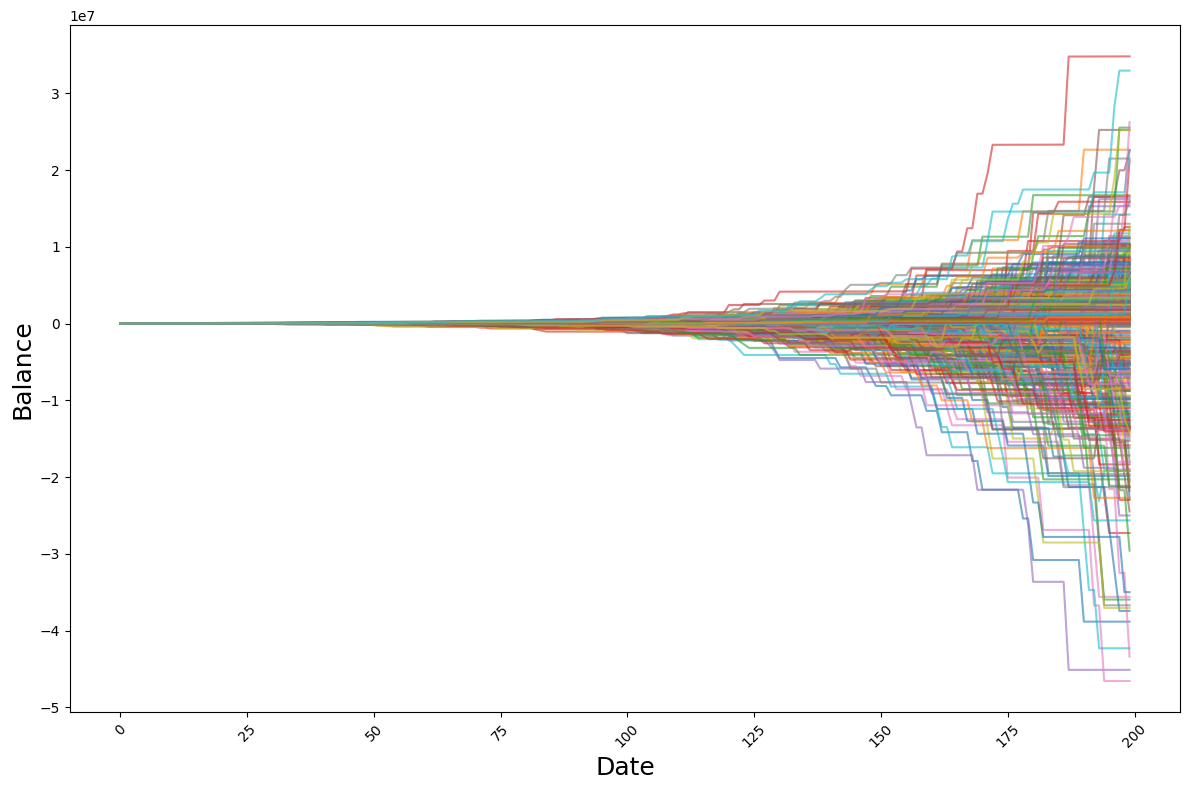

In [9]:
# Plot the balance evolution for all users (columns) as separate lines
plt.figure(figsize=(12, 8))

# Plot each column (account balance) as a line
for user in df.columns:
    plt.plot(df.index, df[user], label=f"User {user}", alpha=0.6)

# Add title and labels
# plt.title("Balance Evolution of Users Over Time")
plt.xlabel("Date", fontsize=18)
plt.ylabel("Balance", fontsize=18)

# Rotate x-axis labels for better visibility
plt.xticks(rotation=45)

# Add legend to differentiate users
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Display the plot
plt.tight_layout()
plt.show()

# Balance Distribution

### First and last day

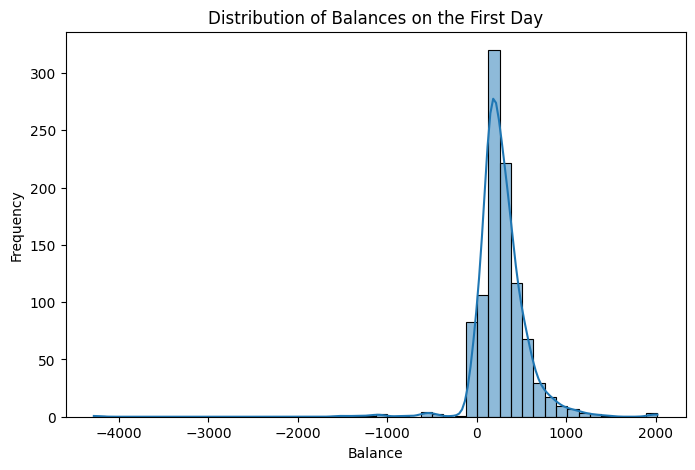

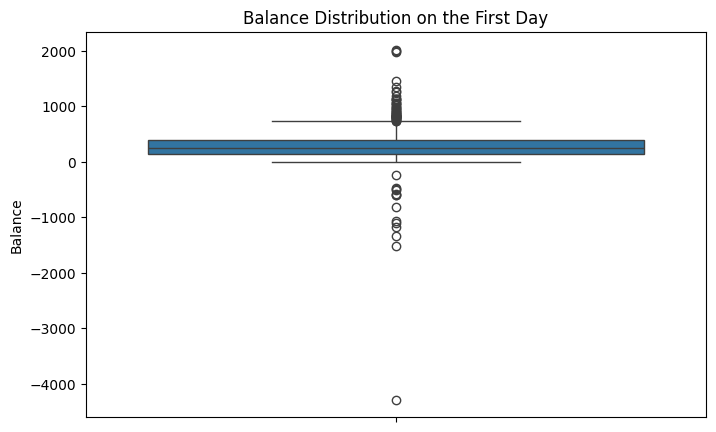

In [10]:
# Select the balances on the first day
first_day_balances = df.iloc[0]

# Plot histogram
plt.figure(figsize=(8, 5))
sns.histplot(first_day_balances, bins=50, kde=True)
plt.xlabel("Balance")
plt.ylabel("Frequency")
plt.title("Distribution of Balances on the First Day")
plt.show()

# Plot box plot
plt.figure(figsize=(8, 5))
sns.boxplot(y=first_day_balances)
plt.ylabel("Balance")
plt.title("Balance Distribution on the First Day")
plt.show()

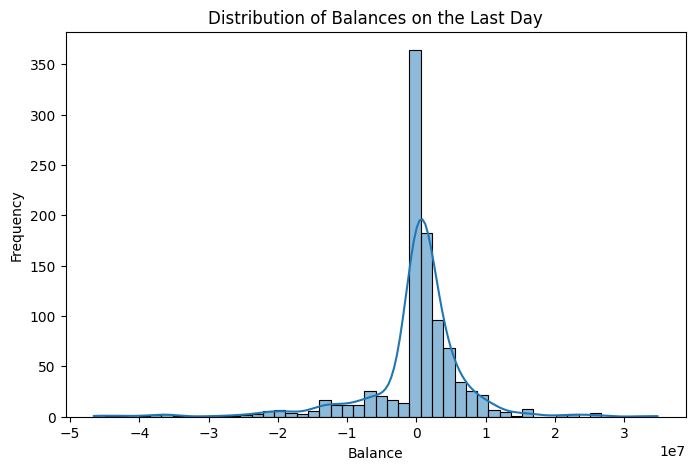

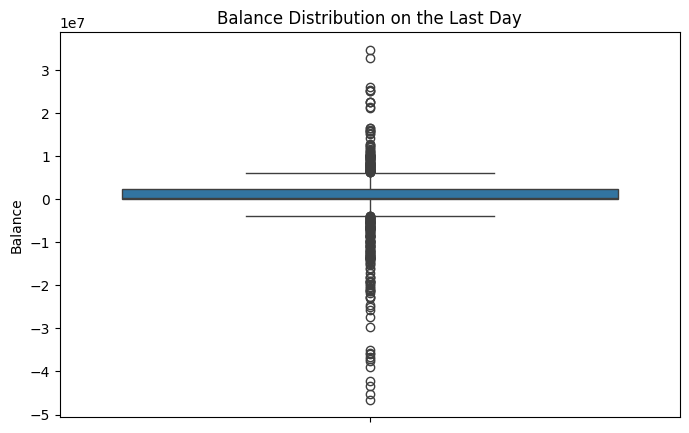

In [11]:
# Select the balances on the first day
last_day_balances = df.iloc[-1]

# Plot histogram
plt.figure(figsize=(8, 5))
sns.histplot(last_day_balances, bins=50, kde=True)
plt.xlabel("Balance")
plt.ylabel("Frequency")
plt.title("Distribution of Balances on the Last Day")
plt.show()

# Plot box plot
plt.figure(figsize=(8, 5))
sns.boxplot(y=last_day_balances)
plt.ylabel("Balance")
plt.title("Balance Distribution on the Last Day")
plt.show()

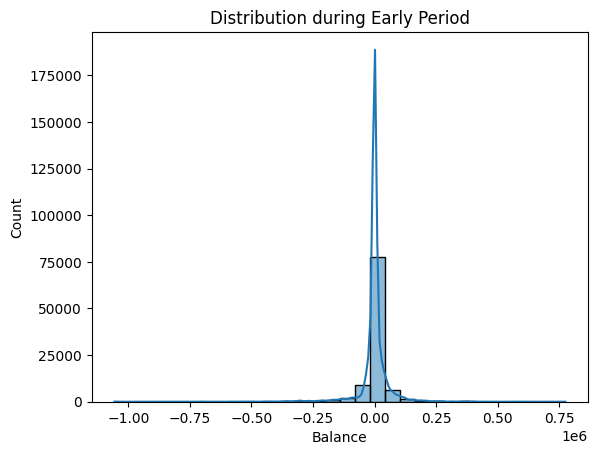

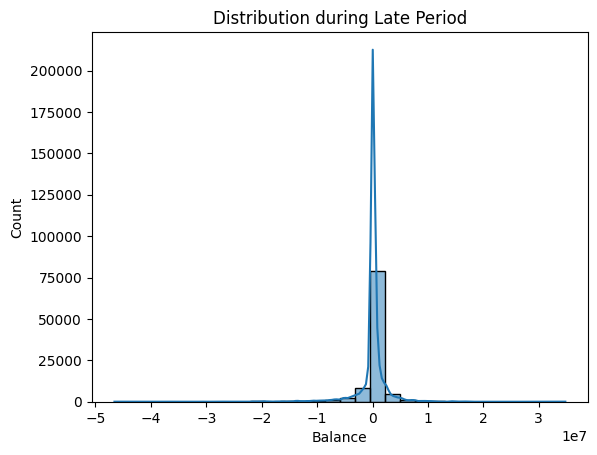

In [12]:
# Split the DataFrame into two parts
early_period = df.iloc[:int(0.5 * len(df))]
late_period  = df.iloc[int(0.5 * len(df)):]

# Plot distribution for early days (aggregated over users and days)
sns.histplot(early_period.values.flatten(), bins=30, kde=True)
plt.title("Distribution during Early Period")
plt.xlabel("Balance")
plt.show()

# Plot distribution for late days
sns.histplot(late_period.values.flatten(), bins=30, kde=True)
plt.title("Distribution during Late Period")
plt.xlabel("Balance")
plt.show()

### Total Distribution

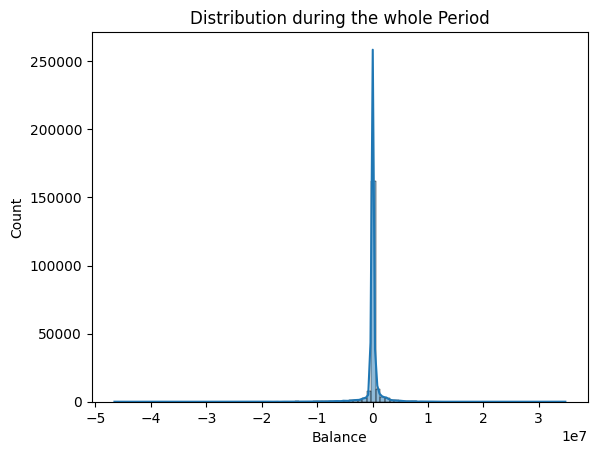

In [13]:
values_df = df.values.flatten()
# Plot distribution for all the days (aggregated over users and days)
sns.histplot(values_df, bins=100, kde=True)
plt.title("Distribution during the whole Period")
plt.xlabel("Balance")
plt.show()

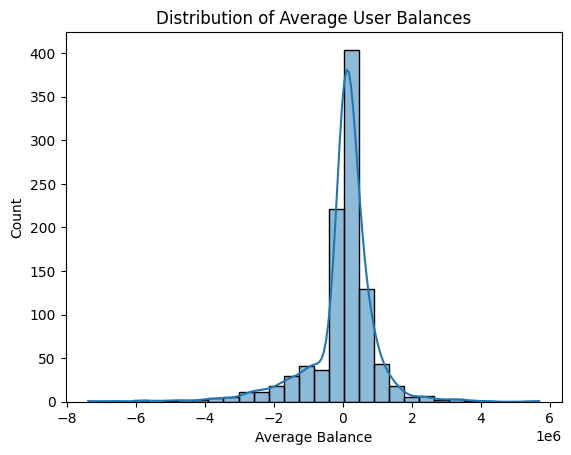

In [14]:
# Compute the mean balance per user over all days
user_means = df.mean(axis=0)

sns.histplot(user_means, bins=30, kde=True)
plt.title("Distribution of Average User Balances")
plt.xlabel("Average Balance")
plt.show()

# Techniques

## CLT

In [15]:
random_users = []

total_account = len(df.columns)

print(f"Total accounts: {total_account}")
random.seed(45)  # Fixes randomness for consistent results

for _ in range(900):
    new = False
    while new == False:
        user = random.randint(0, total_account - 1)
        if user not in random_users:
            new = True
            random_users.append(user)

print(f"Number of extracted random accounts: {len(random_users)}")

Total accounts: 1000
Number of extracted random accounts: 900


In [16]:
days = len(balances) # num of days
weeks = len(balances)//7 # num of weeks
rest = len(balances)%7 # remaining days

In [17]:
clt_distribution = []

# in order to appy CLT -> every week take the mean of the selected users' balances
for i in range(weeks):
    week_data = []
    week_balances = df.iloc[i*7]
    # print(week_balances.name)

    for user in random_users:
    # for user in range(len(df.columns)): -> se prendo tutti gli utenti
        # print(user)
        # print(week_balances[user])
        week_data.append(week_balances[user])
    
    mean = np.mean(week_data)
    clt_distribution.append(round(mean, 2))

/var/folders/s6/4jprwbqj4012tkll2ww6r5hr0000gq/T/ipykernel_18123/536784648.py:13: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  week_data.append(week_balances[user])


In [18]:
clt_distribution = [float(np_float) for np_float in clt_distribution]
clt_distribution

[279.46,
 296.44,
 293.13,
 275.53,
 266.44,
 362.6,
 256.74,
 66.72,
 -108.07,
 -126.9,
 -435.21,
 -351.93,
 -591.1,
 -415.3,
 -727.24,
 -1565.77,
 -2040.35,
 -4680.0,
 -5457.32,
 -9931.91,
 -10314.64,
 -12683.74,
 -9430.23,
 -10465.36,
 -11041.11,
 -29415.99,
 -60414.41,
 -87152.42]

<function matplotlib.pyplot.show(close=None, block=None)>

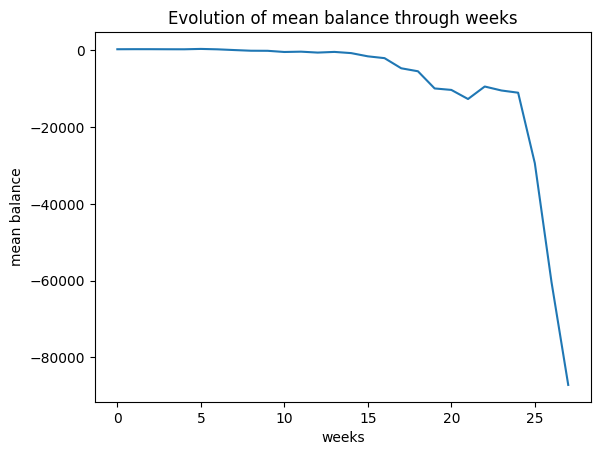

In [19]:
plt.plot(range(weeks), clt_distribution)
plt.xlabel("weeks")
plt.ylabel("mean balance")
plt.title("Evolution of mean balance through weeks")
plt.show

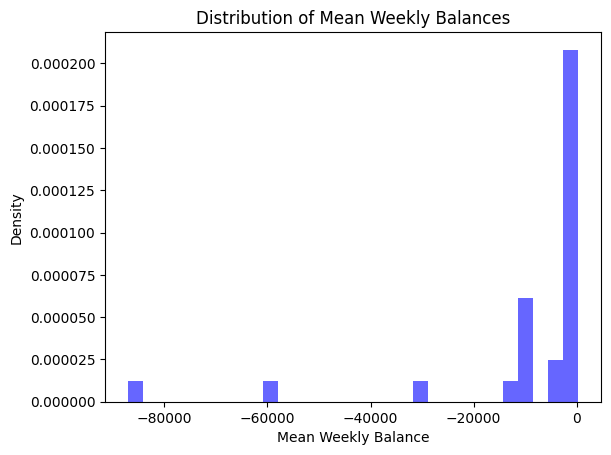

In [20]:
# Histogram to visually inspect the shape of the distribution of the mean balance during weeks
# X axis -> offset +7.469e4 from 74.690 to 74.696
plt.hist(clt_distribution, bins=30, density=True, alpha=0.6, color='b')
plt.xlabel("Mean Weekly Balance")
plt.ylabel("Density")
plt.title("Distribution of Mean Weekly Balances")
plt.show()

In [21]:
# If p > 0.05, the data is likely normally distributed
# If stat -> 1 the data is likely normally distributed
def ks_test(distribution):
    mu = np.mean(distribution)
    std = np.std(distribution)
    ks_stat, ks_p = stats.kstest(distribution, 'norm', args=(mu, std))

    print(f"K-S Test: Statistic={ks_stat:.4f}, p-value={ks_p:.4g}")

    if ks_p < 0.05:
        print("Data is likely NOT normal.")
    else:
        print("Data is likely normal.")

In [22]:
ks_test(clt_distribution)


K-S Test: Statistic=0.3199, p-value=0.004768
Data is likely NOT normal.


In [23]:
clt_mean = np.mean(clt_distribution)
clt_std = np.std(clt_distribution)

# Generate synthetic data using the CLT mean & std
clt_synthetic_data = np.random.normal(loc=clt_mean, scale=clt_std, size=(days, total_account))

# Convert to DataFrame
df_clt = pd.DataFrame(clt_synthetic_data)

In [24]:
values_df_clt = df_clt.values.flatten()

ks_test(values_df_clt)

K-S Test: Statistic=0.0019, p-value=0.4446
Data is likely normal.


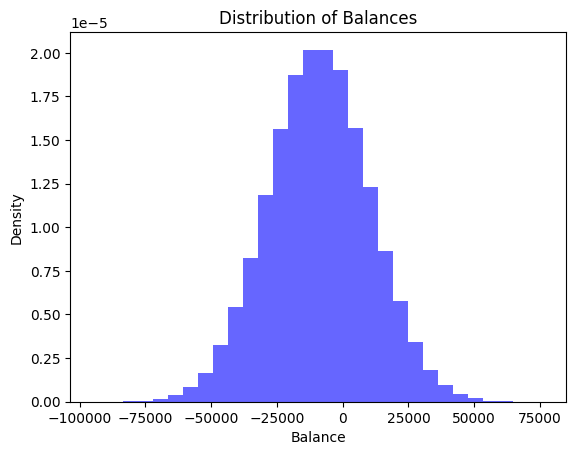

In [25]:
plt.hist(values_df_clt, bins=30, density=True, alpha=0.6, color='b')
plt.xlabel("Balance")
plt.ylabel("Density")
plt.title("Distribution of Balances")
plt.show()

## Log -> negative numbers

In [26]:
df_log = np.log(df + 1e9) # to avoid negative numbers
# df_log = np.log(df)

In [27]:
# Flatten the DataFrame values into a single array
values_df_log = df_log.values.flatten()

nan_count = np.isnan(values_df_log).sum()
print("Number of NaN values:", nan_count)

Number of NaN values: 0


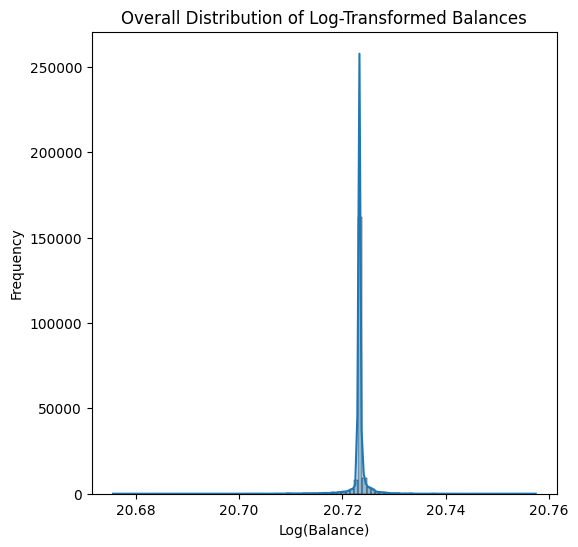

In [28]:
plt.figure(figsize=(6, 6))
sns.histplot(values_df_log, kde=True, bins=100, edgecolor='black')
plt.title("Overall Distribution of Log-Transformed Balances")
plt.xlabel("Log(Balance)")
plt.ylabel("Frequency")
plt.show()

Can't be computed due to negative numbers

In [29]:
ks_test(values_df_log)

K-S Test: Statistic=0.3785, p-value=0
Data is likely NOT normal.


## Wold

In [30]:
# Difference with previous row
df_w = df.diff().dropna()  # drop the first row which will be NaN

values_df_w = df_w.values.flatten()

# Remove NaN values (from the first differencing step)
values_df_w = values_df_w[~np.isnan(values_df_w)]

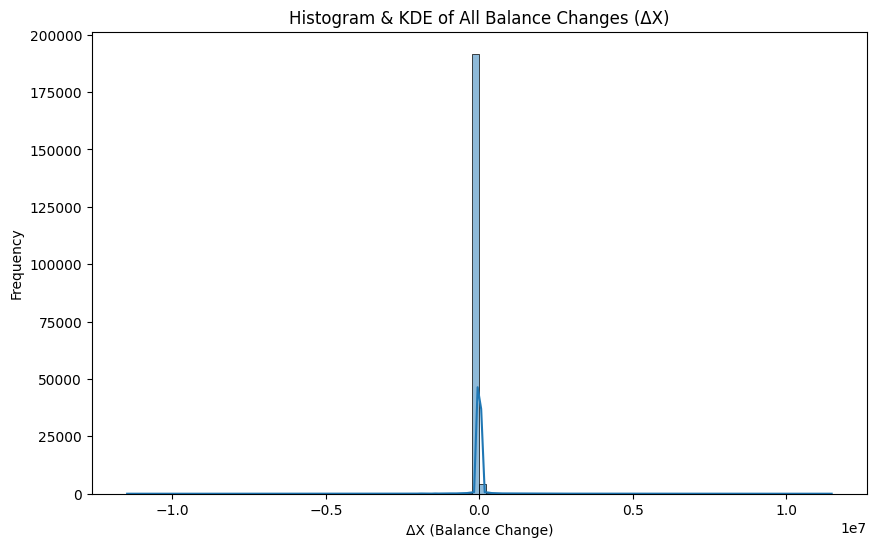

In [31]:
plt.figure(figsize=(10, 6))
sns.histplot(values_df_w, kde=True, bins=100, edgecolor='black')
plt.title("Histogram & KDE of All Balance Changes (ΔX)")
plt.xlabel("ΔX (Balance Change)")
plt.ylabel("Frequency")
plt.show()

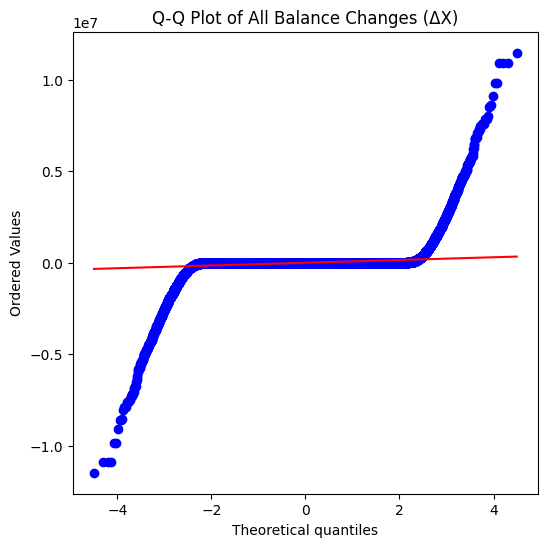

In [32]:
plt.figure(figsize=(6, 6))
stats.probplot(values_df_w, dist="norm", plot=plt)
plt.title("Q-Q Plot of All Balance Changes (ΔX)")
plt.show()

In [33]:
ks_test(values_df_w)

K-S Test: Statistic=0.4773, p-value=0
Data is likely NOT normal.


## Geometric brownian -> negative numbers

In [34]:
df_gmb = np.log((df / df.shift(1)) + 1e9) # Compute r_t = log(X_t / X_{t-1}) for each user
df_gmb = df_gmb.dropna()  # Remove the first row which will be NaN

# Flatten the DataFrame into a 1D array
values_df_gmb = df_gmb.values.flatten()

# Remove any potential NaN values
values_df_gmb = values_df_gmb[~np.isnan(values_df_gmb)]

/opt/anaconda3/envs/bank/lib/python3.9/site-packages/pandas/core/internals/blocks.py:393: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)


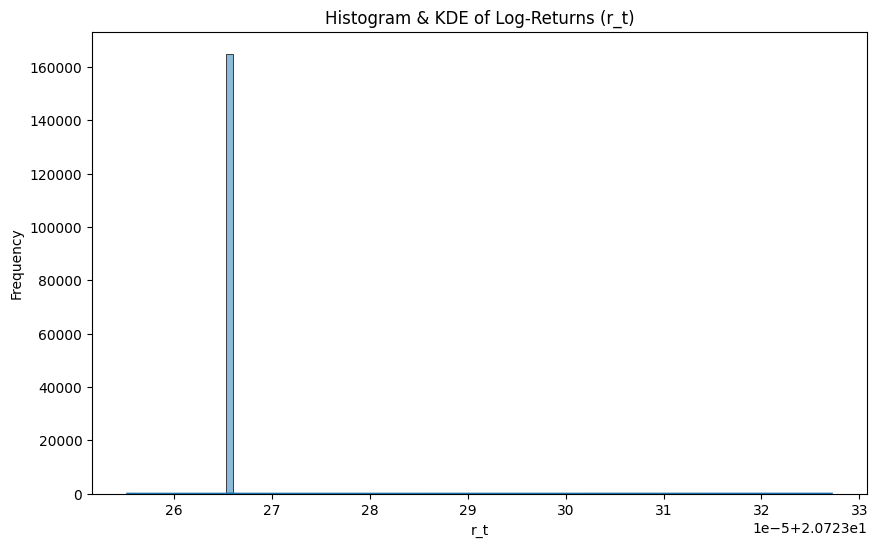

In [35]:
plt.figure(figsize=(10, 6))
sns.histplot(values_df_gmb, kde=True, bins=100, edgecolor='black')
plt.title("Histogram & KDE of Log-Returns (r_t)")
plt.xlabel("r_t")
plt.ylabel("Frequency")
plt.show()

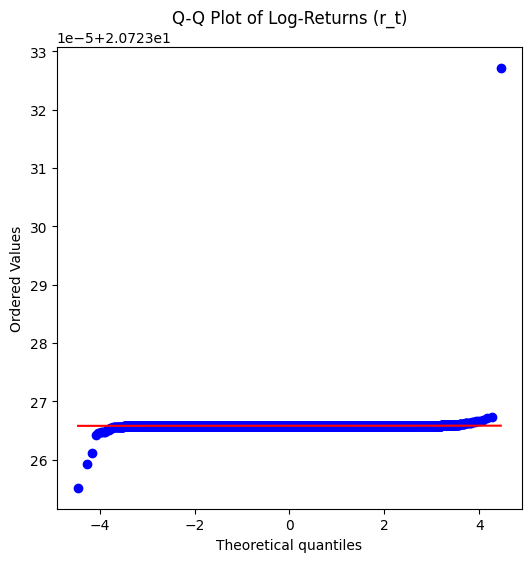

In [36]:
plt.figure(figsize=(6, 6))
stats.probplot(values_df_gmb, dist="norm", plot=plt)
plt.title("Q-Q Plot of Log-Returns (r_t)")
plt.show()

In [37]:
ks_test(values_df_gmb)

K-S Test: Statistic=0.4912, p-value=0
Data is likely NOT normal.


# Squic

In [38]:
def compute_squic(df, l):
    Y = df.T.to_numpy()  # Transpose to get shape (users, days)

    [X,_,_,_,_,_] = squic.run(Y,l)

    print(X.todense())
    return X

def count_zero(X):
    # Count nonzero elements in X
    num_nonzero = X.nnz

    # Compute sparsity level
    total_elements = X.shape[0] * X.shape[1]
    sparsity = num_nonzero / total_elements

    print(f"Number of nonzero elements: {num_nonzero}")
    print(f"Sparsity level: {sparsity:.4f}")

def nnz(X, rows):
    # Count nonzero elements in X
    nnz = X.nnz
    nnz_r = nnz / rows
    return nnz, nnz_r

def sparsity_pattern(X):
    plt.figure(figsize=(10, 10))
    plt.spy(X, markersize=5)  # Adjust markersize for better visibility
    # plt.title("Sparsity Pattern of Precision Matrix (X)")
    plt.show()

In [39]:
l = [1e-3, 1e-4, 1e-5, 1e-6]

## Squic DF

In [40]:
rho_df = {}

In [41]:
import time

In [42]:
data_nnz = []
data_nnzr = []
data_time = []

for rho in l:
    start = time.time()
    X_df = compute_squic(df, rho)
    end = round(time.time() - start, 2)
    rho_df[rho] = X_df
    print(f"time required: {end} seconds")

    count_zero(rho_df[rho])
    nonz, nonz_r = nnz(rho_df[rho], 1000)

    data_nnz.append(nonz)
    data_nnzr.append(nonz_r)
    data_time.append(end)

    if nonz != 1000 and nonz != 1000*1000:
        print(f"For rho = {rho} there are some nnz")
        sparsity_pattern(rho_df[rho])
        print(f"nnz = {nonz}")
        print(f"nnz/row = {nonz_r}")
    else:
        print(f"For rho = {rho} just element on the diagonal")


data_df = [
    ["NNZ"] + data_nnz,
    ["NNZ/Row"] + data_nnzr,
    ["Time (s)"] + data_time
]

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           1000 x 200 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      1.000000e-03 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=5.21e-02 nnz(S)/p=1.00e+03
# Cholesky Failed: Exiting at current iterate.#SQUIC Finished: time=6.08e-01 nnz(X,W)/p=[1.00e+03 1.00e+00] 

[[1. 0. 0. ... 0. 0. 0.]
 [0. 1. 0. ... 0. 0. 0.]
 [0. 0. 1. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 1. 0. 0.]
 [0. 0. 0. ... 0. 1. 0.]
 [0. 0. 0. ... 0. 0. 1.]]
time required: 0

## Squic CLT

In [43]:
# rho_clt = {}

run for more than 340 min without ending

In [44]:
# for rho in l:
#     if rho != 1e-3:
#         X_clt = compute_squic(df_clt, rho)
#         rho_clt[rho] = X_clt

#         count_zero(rho_clt[rho])

#         if nnz(rho_clt[rho]) != len(df.columns):
#             print(f"For rho = {rho} there are some nnz")
#             sparsity_pattern(rho_clt[rho], rho)
#         else:
#             print(f"For rho = {rho} just element on the diagonal")

In [45]:
# sparsity_pattern(rho_clt[1e-3], 1e-3)

In [46]:
# for rho in l:
#     count_zero(rho_clt[rho])

In [47]:
# for rho in l:
#     if nnz(rho_clt[rho]) != len(df.columns):
#         sparsity_pattern(rho_clt[rho])
#     else:
#         print(f"For rho = {rho} just element on the diagonal")

## Squic Log

In [48]:
rho_log = {}

In [49]:
# data_nnz = []
# data_nnzr = []
# data_time = []

# for rho in l:
#     start = time.time()
#     X_df = compute_squic(df_clt, rho)
#     end = round(time.time() - start, 2)
#     rho_log[rho] = X_df
#     print(f"time required: {end} seconds")

#     count_zero(rho_log[rho])
#     nonz, nonz_r = nnz(rho_log[rho], 1000)

#     data_nnz.append(nonz)
#     data_nnzr.append(nonz_r)
#     data_time.append(end)

#     if nonz != 1000 and nonz != 1000*1000:
#         print(f"For rho = {rho} there are some nnz")
#         sparsity_pattern(rho_log[rho])
#         print(f"nnz = {nonz}")
#         print(f"nnz/row = {nonz_r}")
#     else:
#         print(f"For rho = {rho} just element on the diagonal")

# data_log = [
#     ["NNZ"] + data_nnz,
#     ["NNZ/Row"] + data_nnzr,
#     ["Time (s)"] + data_time
# ]

## Squic Wold

In [50]:
l = [1e-4, 1e-5, 1e-6]

In [51]:
rho_w = {}

In [ ]:
data_nnz = []
data_nnzr = []
data_time = []

for rho in l:
    start = time.time()
    X_df = compute_squic(df_w, rho)
    end = round(time.time() - start, 2)
    rho_w[rho] = X_df
    print(f"time required: {end} seconds")

    count_zero(rho_w[rho])
    nonz, nonz_r = nnz(rho_w[rho], 1000)

    data_nnz.append(nonz)
    data_nnzr.append(nonz_r)
    data_time.append(end)

    if nonz != 1000 and nonz != 1000*1000: # modify this if (add brancj for full dense matrix)
        print(f"For rho = {rho} there are some nnz")
        sparsity_pattern(rho_w[rho])
        print(f"nnz = {nonz}")
        print(f"nnz/row = {nonz_r}")
    else:
        print(f"For rho = {rho} just element on the diagonal")

data_w = [
    ["NNZ"] + data_nnz,
    ["NNZ/Row"] + data_nnzr,
    ["Time (s)"] + data_time
]

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           1000 x 199 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      1.000000e-04 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=5.67e-02 nnz(S)/p=1.00e+03
* iter=1 time=5.12e-01 obj=4.63e+13 |delta(obj)|/obj=5.71e-01 nnz(X,L,W)/p=[1.00e+03 5.00e+02 1.35e+00] lns_iter=44 
* iter=2 time=1.55e+00 obj=3.83e+13 |delta(obj)|/obj=2.10e-01 nnz(X,L,W)/p=[1.00e+03 5.00e+02 6.23e+01] lns_iter=45 
* iter=3 time=1.22e+01 obj=2.10e+13 |delta(obj)|

## Squic GMB

In [50]:
rho_gmb = {}

In [51]:
data_nnz = []
data_nnzr = []
data_time = []

for rho in l:
    start = time.time()
    X_df = compute_squic(df_gmb, rho)
    end = round(time.time() - start, 2)
    rho_gmb[rho] = X_df
    print(f"time required: {end} seconds")

    count_zero(rho_gmb[rho])
    nonz, nonz_r = nnz(rho_gmb[rho], 1000)

    data_nnz.append(nonz)
    data_nnzr.append(nonz_r)
    data_time.append(end)

    if nonz != 1000 and nonz != 1000*1000:
        print(f"For rho = {rho} there are some nnz")
        sparsity_pattern(rho_gmb[rho])
        print(f"nnz = {nonz}")
        print(f"nnz/row = {nonz_r}")
    else:
        print(f"For rho = {rho} just element on the diagonal")

data_gmb = [
    ["NNZ"] + data_nnz,
    ["NNZ/Row"] + data_nnzr,
    ["Time (s)"] + data_time
]

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           1000 x 200 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      1.000000e-03 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=5.42e-02 nnz(S)/p=1.00e+03
# Cholesky Failed: Exiting at current iterate.#SQUIC Finished: time=5.88e-01 nnz(X,W)/p=[1.00e+03 1.00e+00] 

[[1. 0. 0. ... 0. 0. 0.]
 [0. 1. 0. ... 0. 0. 0.]
 [0. 0. 1. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 1. 0. 0.]
 [0. 0. 0. ... 0. 1. 0.]
 [0. 0. 0. ... 0. 0. 1.]]
time required: 0

In [131]:
# table = []
# df_tab = []
# df_clt = []
# df_log = []
# df_w = []
# df_gmb = []

# results = [df_tab, df_clt, df_log, df_w, df_gmb]
# rhos = [rho_df, rho_clt, rho_log, rho_w, rho_gmb]

# for i, res in enumerate(results):
#     for rho in l:
#         res.append(nnz(rhos[i][rho]))
#     table.append(res)


# # for rho in l:
# #     df_tab.append(nnz(rho_df[rho]))
# # table.append(df_tab)

# # for rho in l:
# #     df_log.append(nnz(rho_log[rho]))
# # table.append(df_log)

# # for rho in l:
# #     df_gmb.append(nnz(rho_gmb[rho]))
# # table.append(df_gmb)

# print(tabulate(table, headers=l, tablefmt="grid"))

## Squic-run

2 consecutive SQUIC calls, with the 2nd one using as a bias negative offdiagonals of the first matrix estimation. Then we keep only the structure and the weights of only the negative offdiagonal entries (from the 2nd precision matrix estimation).

In [132]:
def squic_fit(Y, l1, l2, eta, kappa, tau):
    # # First squic call -> Identify negative off-diagonal elements (Equation 9)
    X1, _, _, _, _, _ = squic.run(Y, l1)
    Theta1 = X1.todense()
    
    # Step 2: Build Graphical Bias G (Equation 10)
    G = np.zeros_like(Theta1)
    G[np.triu_indices_from(G, k=1)] = (Theta1[np.triu_indices_from(Theta1, k=1)] < -kappa).astype(int)
    G += G.T  # Make symmetric
    
    # Step 3: Build Regularization Parameter Matrix Λ (Equation 12)
    Lambda = np.full_like(Theta1, l1) 
    # Apply eta where G is nonzero
    Lambda[G != 0] = eta
    
    # Step 4: Second SQUIC estimation with bias (Equation 11)
    X2, _, _, _, _, _ = squic.run(Y, l2, M=Lambda)
    Theta2 = X2.todense()
    
    # Step 5: Construct the final M-matrix (Equation 13)
    Theta_final = np.zeros_like(Theta2)
    
    # Get diagonal
    diag = np.diag(Theta2)
    
    # Identify negative off-diagonal elements
    n = Theta2.shape[0]
    for i in range(n):
        for j in range(i+1, n):
            if Theta2[i, j] < -tau:
                Theta_final[i, j] = Theta2[i, j]
                Theta_final[j, i] = Theta2[j, i]
    
    # Restore diagonal
    np.fill_diagonal(Theta_final, diag)
    
    return Theta_final

In [133]:
Y = df_log.T.to_numpy()  # Convert to (users, days)
theta = squic_fit(Y, l1=1e-6, l2=1e-6, eta=1e-7, kappa=0.1, tau=0.05)

----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           1000 x 200 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      1.000000e-06 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=1.03e-02 nnz(S)/p=1.90e+02
* iter=1 time=3.28e-02 obj=-6.93e+02 |delta(obj)|/obj=1.00e+00 nnz(X,L,W)/p=[1.90e+02 9.89e+01 1.00e+00] lns_iter=1 
* iter=2 time=1.16e-01 obj=-1.39e+03 |delta(obj)|/obj=5.00e-01 nnz(X,L,W)/p=[1.90e+02 9.89e+01 1.00e+00] lns_iter=1 
* iter=3 time=1.92e-01 obj=-2.08e+03 |delta(obj)

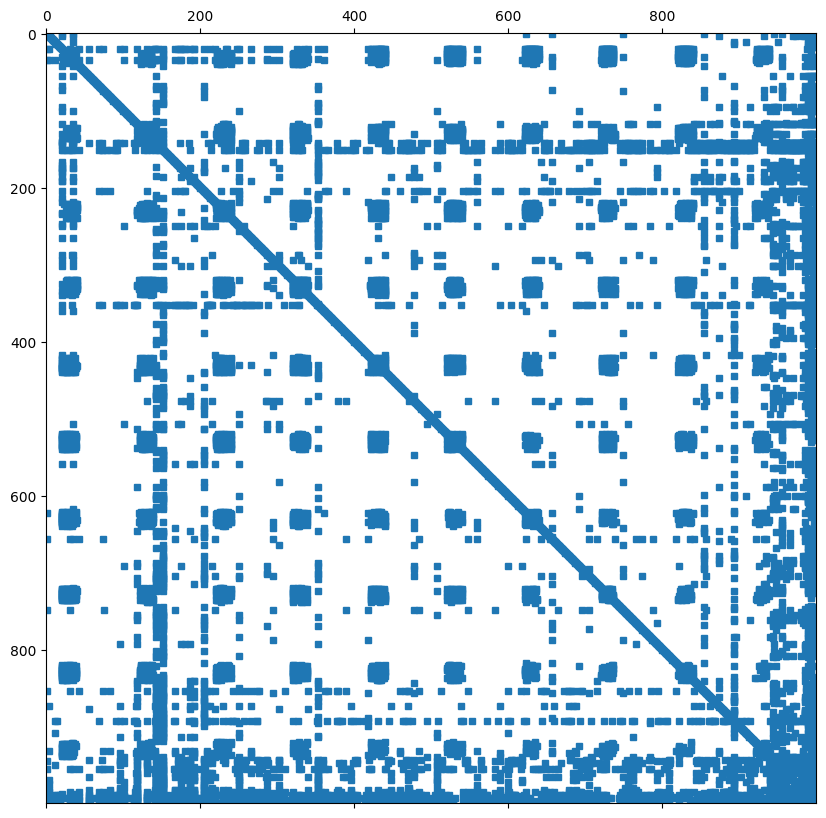

In [134]:
sparsity_pattern(theta)

In [135]:
# Y = df_gmb.T.to_numpy()  # Convert to (users, days)
# theta = squic_fit(Y, l1=1e-6, l2=1e-6, eta=1e-7, kappa=0.1, tau=0.05)
# sparsity_pattern(theta)

In [136]:
# Y = df_w.T.to_numpy()  # Convert to (users, days)
# theta = squic_fit(Y, l1=1e-6, l2=1e-6, eta=1e-7, kappa=0.1, tau=0.05)
# sparsity_pattern(theta)

In [137]:
import scipy.sparse as sp

def squic_matlab(Y, lambda_val, eta):
    # Get dimensions
    p, _ = Y.shape
    
    # Construct initial Lambda matrix (zero sparse matrix)
    Lambda_matrix = sp.csr_matrix((p, p))

    # cant pass those params cause jupyter crash
    # W0 = Lambda_matrix
    # X0 = Lambda_matrix
    
    print('Squic Run 1: Estimate graphical bias of negatively correlated variables')
    
    # First SQUIC call
    X1, _, _, _, _, _ = squic.run(Y, lambda_val, M=Lambda_matrix)
    
    # Remove diagonal entries and select structure of negative off-diagonal entries
    G_neg = X1.todense() - np.diag(np.diag(X1.todense()))
    G_neg = (G_neg < 0).astype(float)
    
    print('Squic Run 2: Use the graphical bias and select negatively correlated variables')
    
    # Construct Lambda matrix
    Lambda_matrix = sp.csr_matrix(eta * G_neg)
    
    # Second SQUIC call
    X2,  _, _, _, _, _ = squic.run(Y, lambda_val, M=Lambda_matrix)
    
    # Remove diagonal entries
    W = X2.todense() - np.diag(np.diag(X2.todense()))
    
    # Create the adjacency matrix with weights
    #  Select the negative off-diagonal entries
    W = np.abs(W) * (W < 0)
    
    return W

Squic Run 1: Estimate graphical bias of negatively correlated variables
----------------------------------------------------------------
                     SQUIC Version 1.0                         
----------------------------------------------------------------
Input Matrices
 nnz(X0)/p:   1.000000e+00
 nnz(W0)/p:   1.000000e+00
 nnz(M)/p:    ignored
 Y:           1000 x 200 
Runtime Configs   
 Sample Cov.:   Deterministic
 CordDec Vers:  Collective coordinate descent update 
 Inversion:     Approx. block Neumann series
 Fact. Routine: CHOLMOD
Parameters       
 verbose:     1 
 lambda:      1.000000e-06 
 max_iter:    100 
 term_tol:    1.000000e-03 
 inv_tol:     1.000000e-04 
 threads:     12 

#SQUIC Started 
* sample covariance matrix S: time=1.28e-02 nnz(S)/p=1.90e+02
* iter=1 time=3.27e-02 obj=-6.93e+02 |delta(obj)|/obj=1.00e+00 nnz(X,L,W)/p=[1.90e+02 9.89e+01 1.00e+00] lns_iter=1 
* iter=2 time=1.16e-01 obj=-1.39e+03 |delta(obj)|/obj=5.00e-01 nnz(X,L,W)/p=[1.90e+02 9.89e+0

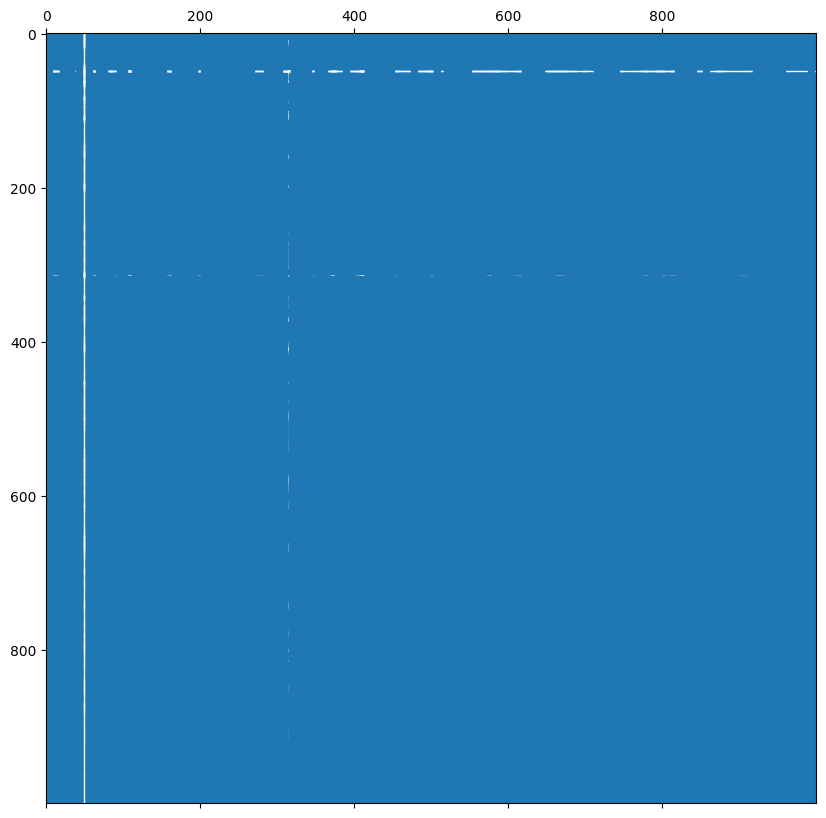

In [140]:
theta3 = squic_matlab(Y, 1e-6, 1e-7)
sparsity_pattern(theta3)